# 00 · Getting to know the input data
**Run this notebook first.** Before any modeling we look at the raw inputs: what we predict, what the features mean, how they relate to the outcome, and how all of that varies across the four hospital sites.

In [ ]:
# --- workshop bootstrap: make the package importable ---
import sys, os

def _find_deliverables_root():
    """Locate the folder that contains src/fedconformal + data/ -- resolves
    relative to this notebook in classic Jupyter/JupyterLab, and searches
    Google Drive (after mounting it) in Colab."""
    candidates = [os.path.abspath(os.path.join(os.getcwd(), '..'))]
    try:
        import google.colab  # noqa: F401
        from google.colab import drive
        if not os.path.isdir('/content/drive/MyDrive'):
            drive.mount('/content/drive')
        root = '/content/drive/MyDrive'
        candidates += [root, os.path.join(root, 'deliverables'),
                       os.path.join(root, 'Colab Notebooks', 'deliverables')]
        for name in sorted(os.listdir(root)):
            candidates.append(os.path.join(root, name))
            candidates.append(os.path.join(root, name, 'deliverables'))
    except ImportError:
        pass
    for c in candidates:
        if os.path.isdir(os.path.join(c, 'src', 'fedconformal')):
            return os.path.abspath(c)
    raise RuntimeError(
        "Could not find the 'deliverables' folder (needs a src/fedconformal "
        "subfolder). In Colab, upload the WHOLE 'deliverables' folder (not just "
        "this notebook) to your Google Drive, then re-run this cell."
    )

_ROOT = _find_deliverables_root()
sys.path.insert(0, os.path.join(_ROOT, 'src'))
import numpy as np, pandas as pd
from fedconformal import data, conformal, evaluate as ev, federated, heterogeneity as het, viz, eda, paper_figures as pf
viz.set_style()
%matplotlib inline
# load the federation once (each notebook is self-contained)
df = data.load_raw()
sites = data.load_sites(shared_scaler=True)

## The dataset in one glance
920 patients from four hospitals, 13 clinical features, one outcome. Each row is one patient's cardiac work-up.

In [4]:
print('patients:', len(df))
print('sites   :', df['site'].unique().tolist())
print('columns :', [c for c in df.columns if c != 'site'])
df.head()

patients: 920
sites   : ['cleveland', 'hungarian', 'switzerland', 'va']
columns : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,site
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland


## What are the classes? (the target)
The target is the **original** UCI `num` column: `0` = no disease and `1`–`4` = disease of increasing severity (roughly, the number of major vessels with >50% narrowing). Unlike many tutorials, we do **not** collapse this to binary — the workshop's default task predicts the full **5-class** severity target directly, so a conformal prediction set is a *subset* of `{No disease, Mild, Moderate, Severe, Critical}`.

raw target values present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
severity class counts:
target
0    411
1    196
2    135
3    135
4     43
Name: count, dtype: int64


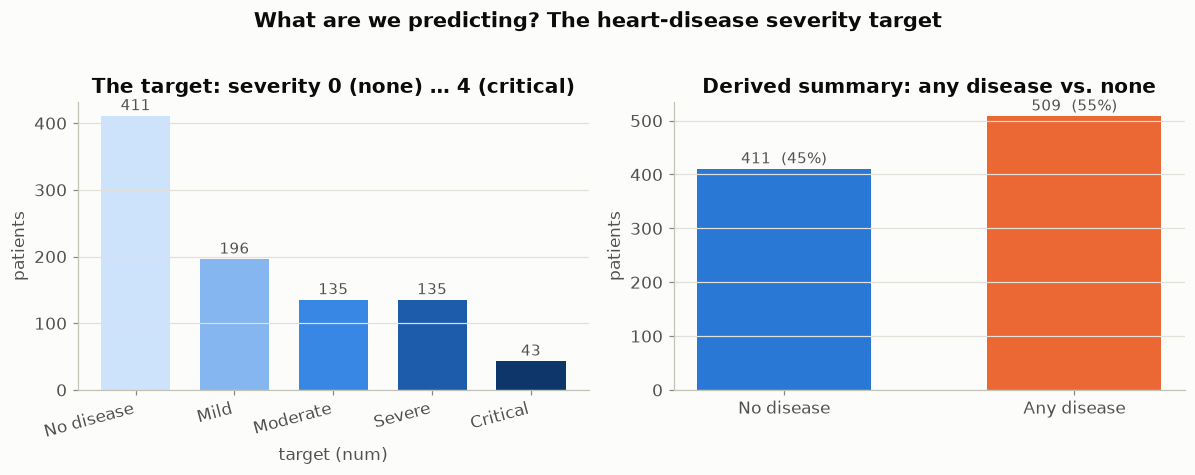

In [5]:
print('raw target values present:', sorted(df['target'].unique()))
print('severity class counts:')
print(df['target'].value_counts().sort_index())
eda.plot_target_distribution(df);

The full cohort skews toward the lower severities, but a derived *any-disease* view is close to balanced (~45% none / ~55% any) — and both pictures are misleading on their own, because the severity mix differs a lot by site:

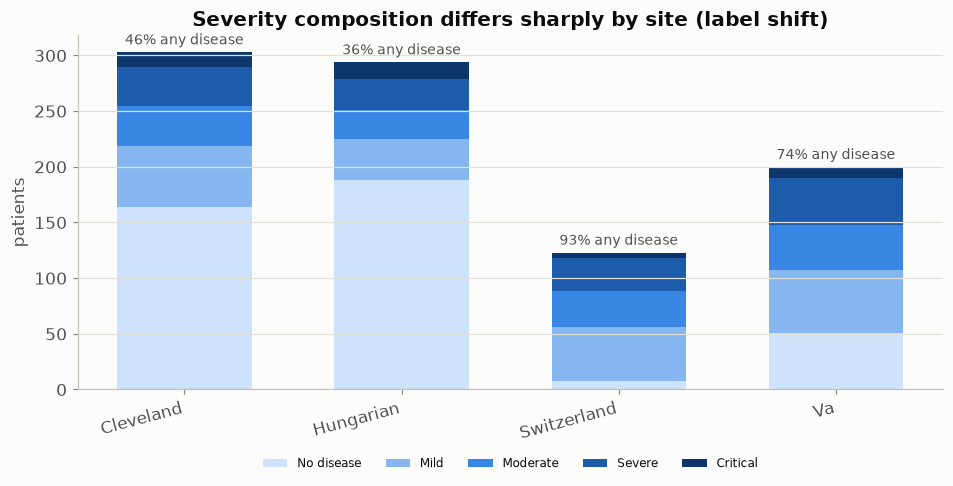

In [6]:
eda.plot_target_by_site(df);

## The 13 features
Five are **continuous** (age, resting blood pressure, cholesterol, max heart rate, ST depression) and eight are **categorical / ordinal** (sex, chest-pain type, fasting blood sugar, resting ECG, exercise angina, ST slope, #vessels, thalassemia test). The full data dictionary is in the `eda` module docstring:

In [7]:
print(eda.__doc__)


Exploratory data analysis (EDA) for the raw UCI Heart Disease inputs.

Before any modeling, attendees should *see* the inputs: what the target classes
are, which features are categorical vs. continuous, how they relate to the
outcome, and how all of this differs across the four hospital sites. These
helpers produce that first-look picture.

Feature dictionary (raw UCI coding)
-----------------------------------
age       : age in years                                     (continuous)
sex       : 1 = male, 0 = female                             (binary)
cp        : chest pain type -- 1 typical angina, 2 atypical,
            3 non-anginal, 4 asymptomatic                    (categorical)
trestbps  : resting blood pressure (mm Hg)                   (continuous)
chol      : serum cholesterol (mg/dl); 0 = unrecorded        (continuous)
fbs       : fasting blood sugar > 120 mg/dl (1 = true)       (binary)
restecg   : resting ECG -- 0 normal, 1 ST-T abnormality,
            2 left-ventricula

### Continuous features by severity
Where the five severity curves (light = none, dark = critical) separate, the feature is informative. Note `chol`, `trestbps`, `thalach` are shown for *measured* values only (zeros are unrecorded).

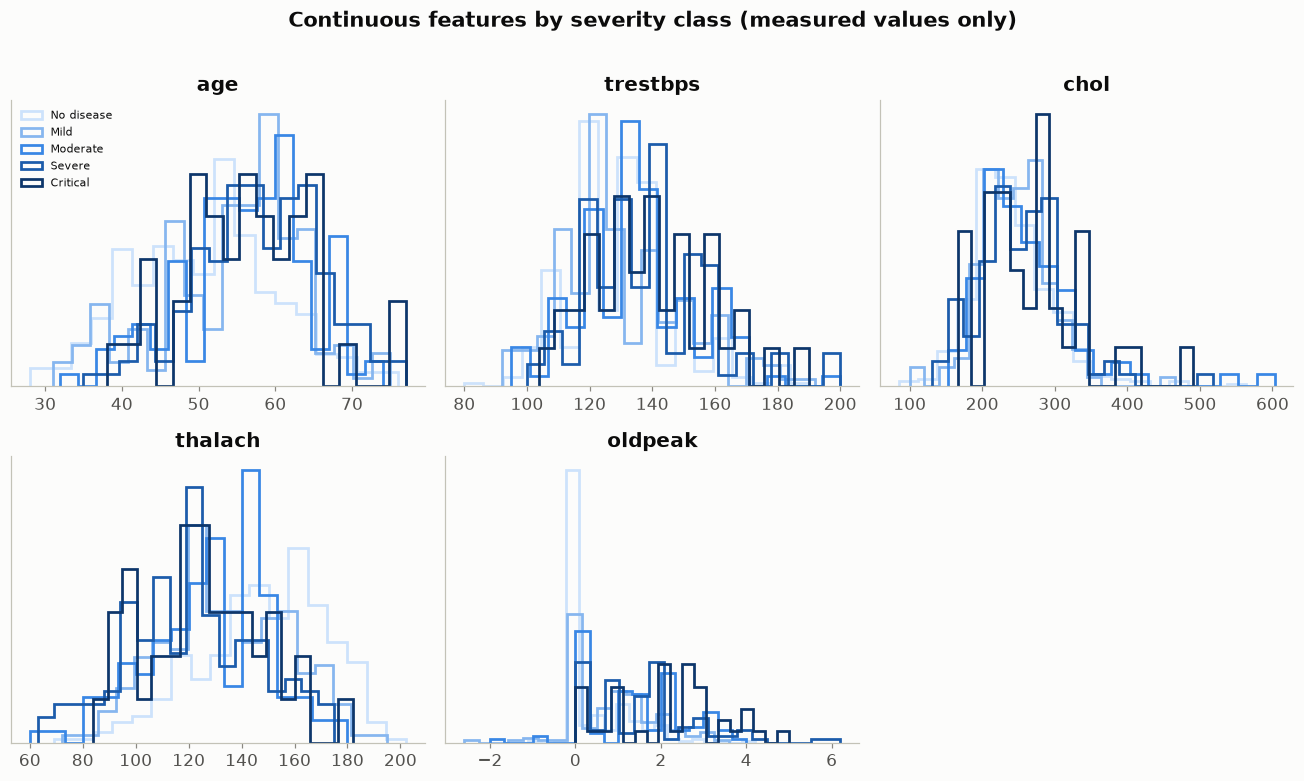

In [8]:
eda.plot_continuous_grid(df);

### Categorical features: mean severity per level
Bar height is the mean severity (0–4) within each category; the dashed line is the overall mean. Asymptomatic chest pain, exercise-induced angina, a flat/down ST slope and a reversible thalassemia defect all carry sharply higher mean severity — clinically sensible.

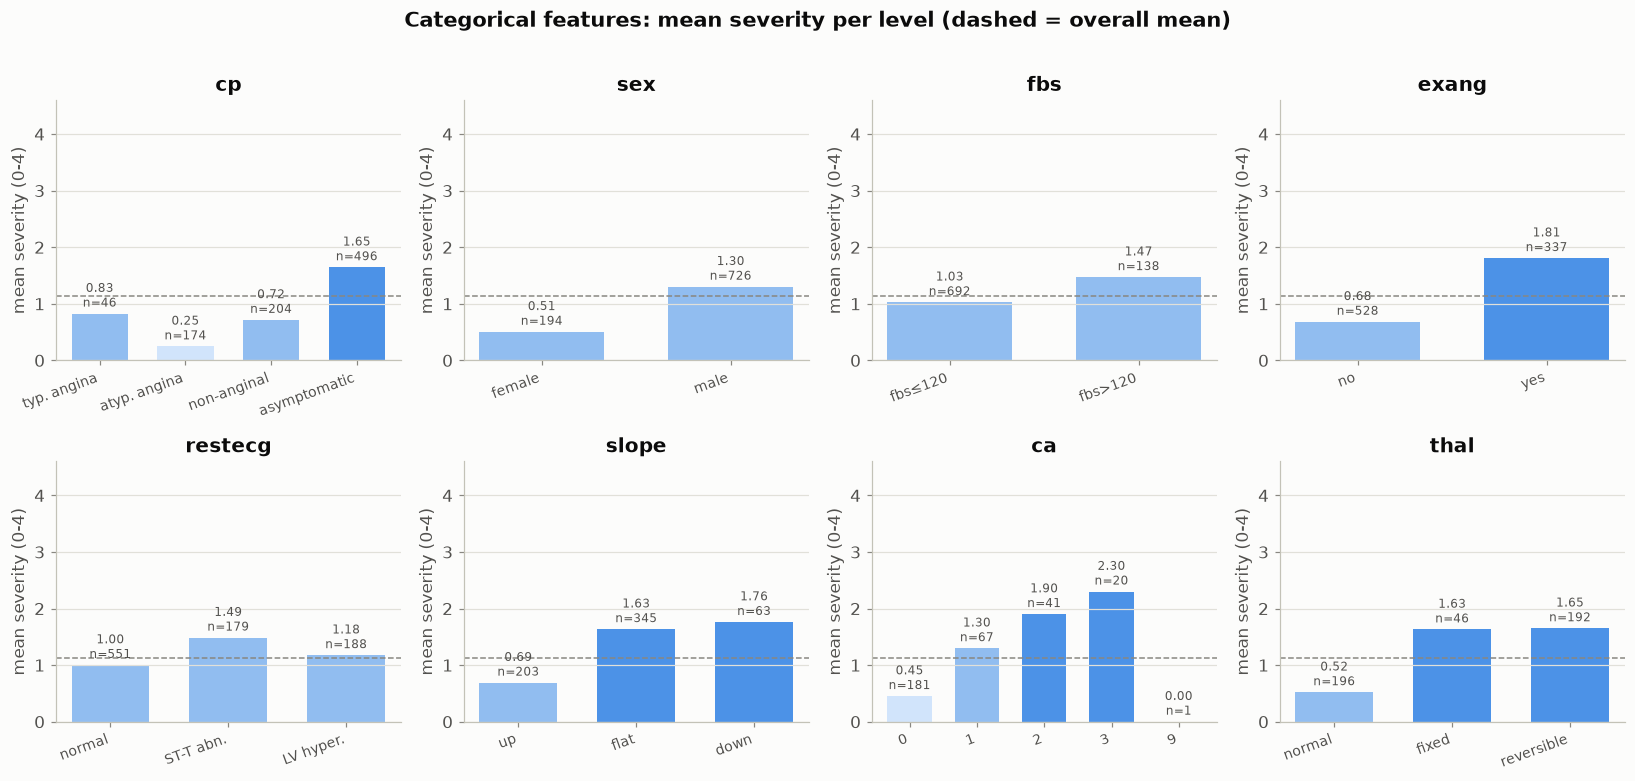

In [9]:
eda.plot_categorical_grid(df);

> **Curation note:** `ca` and `thal` are unrecorded (`?`/`-9` in the raw files, loaded as NaN and dropped here) for the large majority of patients outside Cleveland — a bigger measurement-heterogeneity gap than cholesterol's zero-coded missingness. Spotting these is exactly the measurement-heterogeneity check the workshop is about; see notebook 01.

### One feature across sites
Maximum heart rate achieved, by site — a quick look at how the same measurement shifts between hospitals.

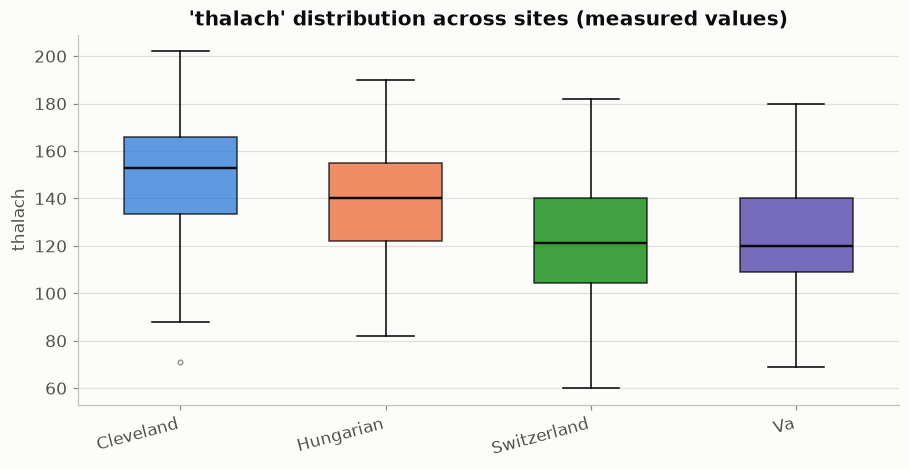

In [10]:
eda.plot_feature_boxplots_by_site(df, 'thalach');

### Correlation structure
How features move together and with the outcome. `cp`, `exang`, `oldpeak`, `thalach` and `ca` are among the strongest correlates of disease.

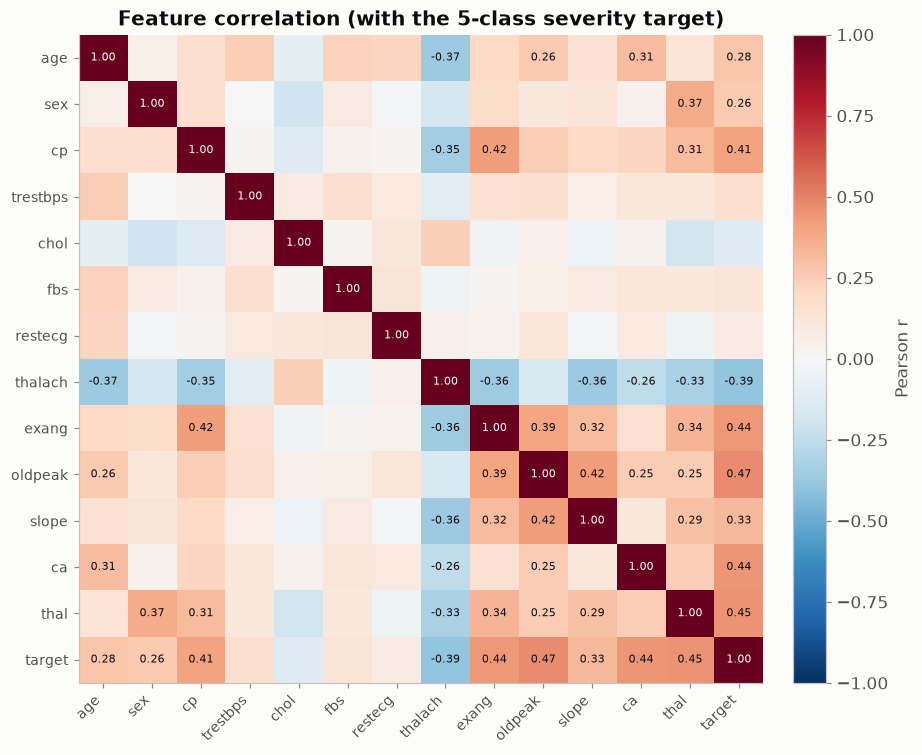

In [9]:
eda.plot_correlation_heatmap(df);

### Exercise
1. Call `eda.plot_feature_boxplots_by_site(df, 'age')` and `'trestbps'`. Which feature is most consistent across sites, and which is most shifted?
2. Using `df`, compute the mean severity (`df['target']`) for males vs females *within each site*. Does the sex effect look the same everywhere? (This previews the heterogeneity notebook.)